In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import mne

import torch
import torch.nn as nn
import torchaudio

from braindecode.models import Labram

import matplotlib.pyplot as plt


In [2]:
raw = mne.io.read_raw_edf("/var/log/thavamount/eeg_dataset/motor_eeg/1.0.0/S001/S001R03.edf", preload=True)
# montage = mne.channels.make_standard_montage('standard_1020') # locations of electrodes
# raw.rename_channels(lambda x: x.rstrip('.')) # remove trailing dots in channel names (making it so that it matches the montage names)
# raw = raw.set_montage(montage, match_case=False)
# raw.plot();

Extracting EDF parameters from /var/log/thavamount/eeg_dataset/motor_eeg/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [3]:
# prints out information about the raw data
raw

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

Using matplotlib as 2D backend.


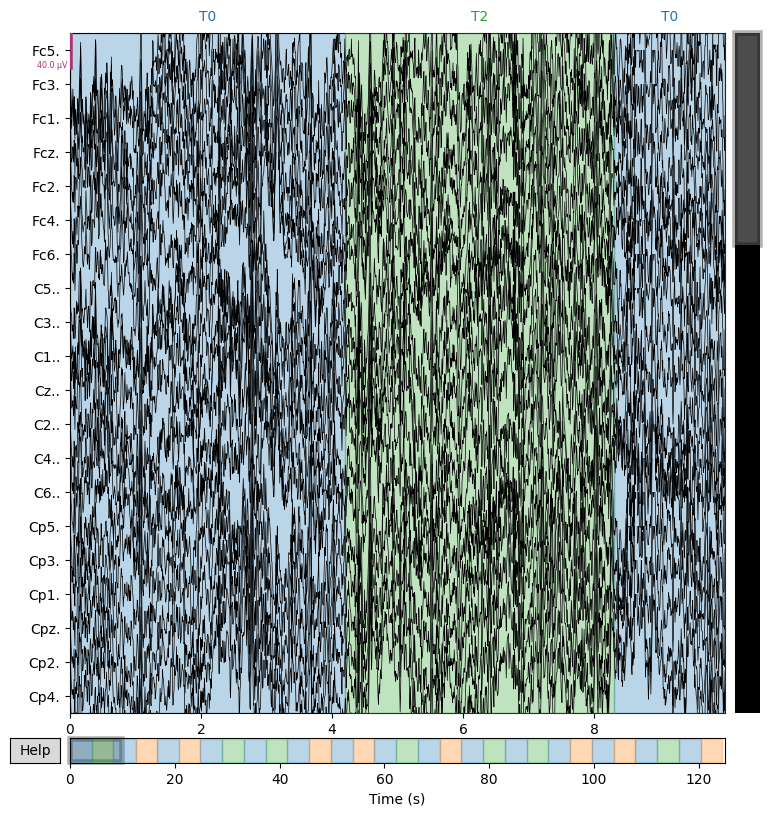

Figure(800x800)


In [4]:
print(raw.plot(duration=10))

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


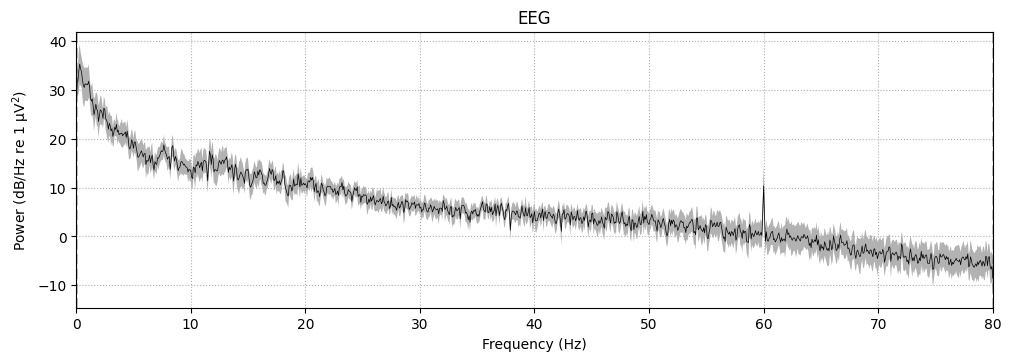

In [5]:
fig = raw.compute_psd(tmax=np.inf, fmax=80).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
);
plt.show()

In [6]:
events, event_ids = mne.events_from_annotations(raw)
epochs = mne.Epochs(raw, events=events)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


In [7]:
print(raw.get_data().shape) # (C, T)
print(events.shape) # every row is [sample, 0, event_id]
print(epochs["2"].get_data().shape) # corresponding to right hand, (n_epochs, C, T)
epochs.get_data().shape # (29, 64, 113)

(64, 20000)
(30, 3)
Using data from preloaded Raw for 8 events and 113 original time points ...
0 bad epochs dropped
(8, 64, 113)
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped


(29, 64, 113)

In [8]:
data_2 = epochs["2"].get_data()
data_2.shape

Using data from preloaded Raw for 8 events and 113 original time points ...


(8, 64, 113)

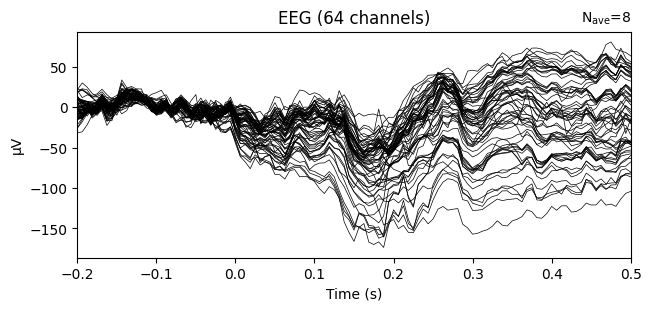

In [9]:
epochs["2"].average().plot();

In [10]:
raw_filt = raw.copy().filter(0.1, 40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 5281 samples (33.006 s)



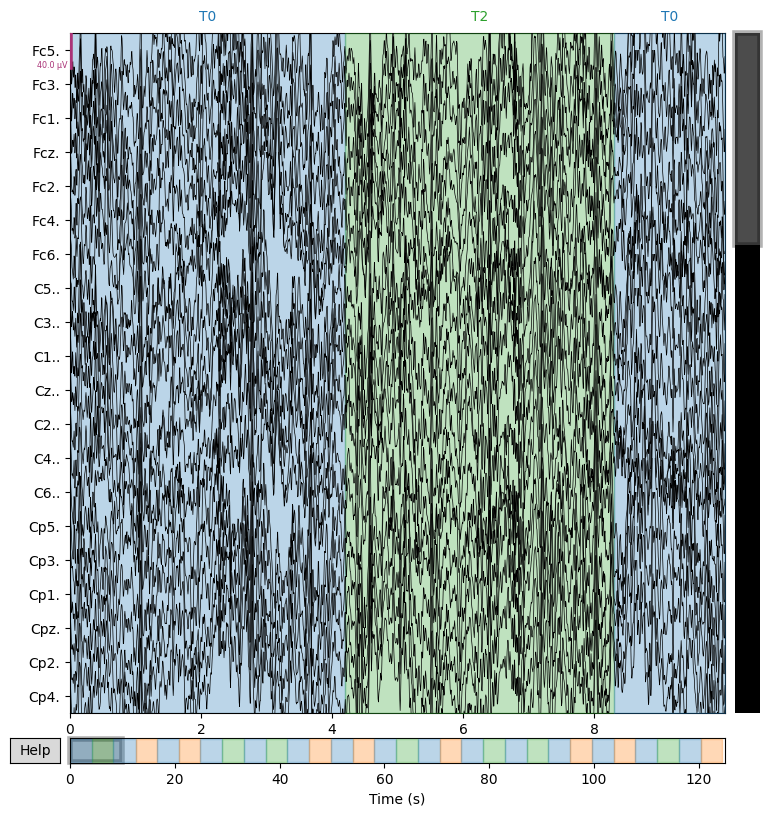

In [11]:
raw_filt.plot(show=False)

Not setting metadata
30 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated


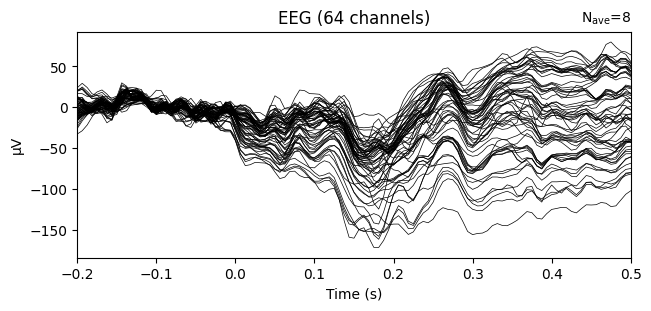

In [12]:
epochs_filt = mne.Epochs(raw_filt, events=events)
epochs_filt["2"].average().plot(show=False)

In [13]:
labram_model = Labram(n_chans=64, n_times=800, n_outputs=0)
# url = "https://huggingface.co/braindecode/Labram-Braindecode/resolve/main/braindecode_labram_base.pt"
state = torch.load("../scripts/models/labram_nc64_nt800_backbone.pt", map_location="cpu")
labram_model.load_state_dict(state)

<All keys matched successfully>

In [14]:
# data preprocessing

labram_raw = raw.copy()
labram_raw

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [15]:
# filter to 0.1-75hz

labram_filt = labram_raw.copy().filter(l_freq=0.1, h_freq=75)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 75 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 75.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 77.50 Hz)
- Filter length: 5281 samples (33.006 s)



Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1057 samples (6.606 s)

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


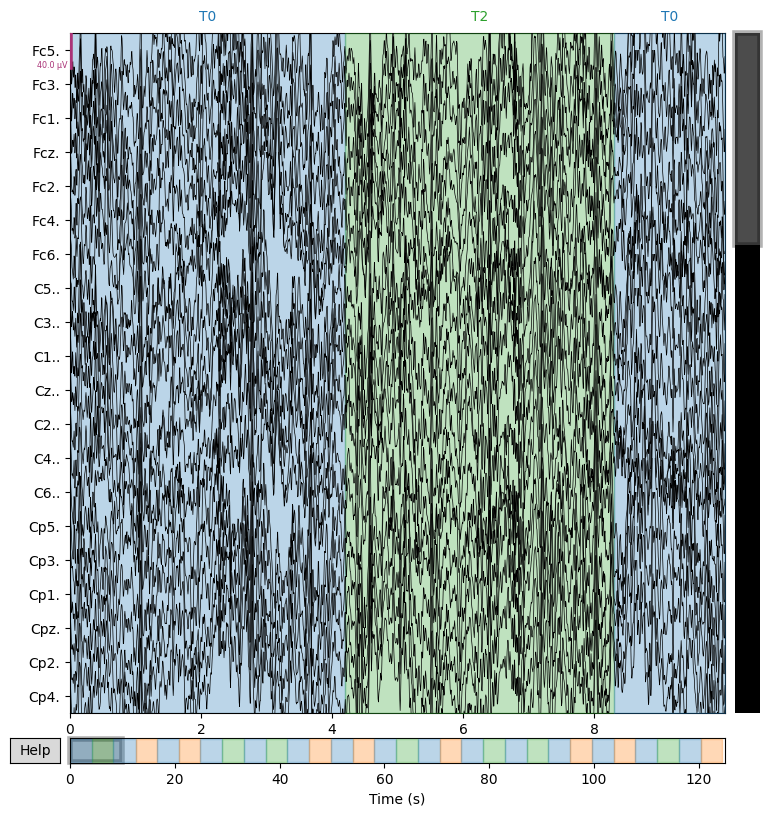

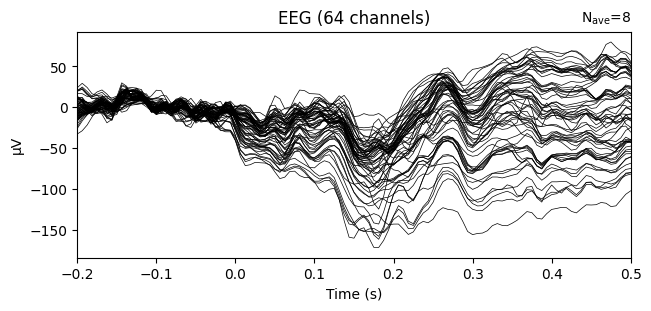

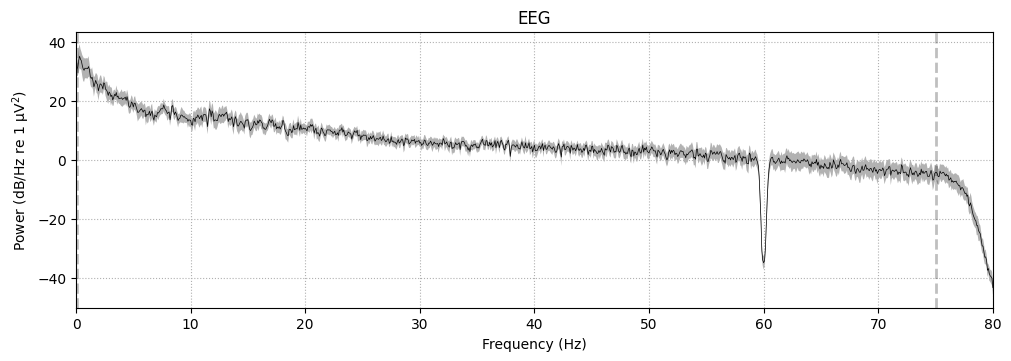

In [16]:
# notch filtering

labram_filt = labram_filt.notch_filter(freqs=60)
fig = labram_filt.compute_psd(tmax=np.inf, fmax=80).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)
plt.show()

In [17]:
# resample data

orig_sr = 160
new_sr = 200

sampler = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=new_sr)
labram_resamp = sampler(torch.tensor(labram_filt.get_data()).float())
labram_resamp.shape

torch.Size([64, 25000])

In [18]:
chunk = labram_resamp[:, :800]
print(chunk.shape)

torch.Size([64, 800])


In [19]:
labram_feat = labram_model.forward_features(chunk.unsqueeze(0), return_patch_tokens=True)
print(labram_feat.shape)

torch.Size([1, 256, 200])


In [20]:
# key conclusion: output of a 4-sec clip @ 200Hz which is (1, 64, 800) -> 4-sec clip @ 50Hz which is (1, 256, 200)

In [21]:
# first experiment on hand classification T0, T1, T2 (3 classes)

# transpose embedding (1, 256, 200) -> (1, 200, 256)
# linear layer from 256 to 3 (num_classes) -> (1, 200, 3)
# then resample original data to 50 Hz, and cross-entropy between gt (1, 200) and output (1, 200, 3)

In [22]:
labram_model.train

<bound method Module.train of Labram(
  (patch_embed): Sequential(
    (segment_patch): _SegmentPatch(
      (patcher): Conv1d(1, 200, kernel_size=(200,), stride=(200,))
      (adding_extra_dim): Rearrange('batch nchans temporal -> (batch nchans) 1 temporal')
    )
    (temporal_conv): _TemporalConv(
      (channel_patch_flatten): Rearrange('Batch chs npat spatch -> Batch () (chs npat) spatch')
      (conv1): Conv2d(1, 8, kernel_size=(1, 15), stride=(1, 8), padding=(0, 7))
      (act_layer_1): GELU(approximate='none')
      (norm1): GroupNorm(4, 8, eps=1e-05, affine=True)
      (conv2): Conv2d(8, 8, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
      (act_layer_2): GELU(approximate='none')
      (norm2): GroupNorm(4, 8, eps=1e-05, affine=True)
      (conv3): Conv2d(8, 8, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
      (norm3): GroupNorm(4, 8, eps=1e-05, affine=True)
      (act_layer_3): GELU(approximate='none')
      (transpose_temporal_channel): Rearrange('Batch C NA T -

In [23]:
resampled, resampled_events = raw.copy().resample(sfreq=50, events=events)

In [24]:
resampled_events

array([[   0,    0,    1],
       [ 210,    0,    3],
       [ 415,    0,    1],
       [ 625,    0,    2],
       [ 830,    0,    1],
       [1040,    0,    2],
       [1245,    0,    1],
       [1455,    0,    3],
       [1660,    0,    1],
       [1870,    0,    3],
       [2075,    0,    1],
       [2285,    0,    2],
       [2490,    0,    1],
       [2700,    0,    2],
       [2905,    0,    1],
       [3115,    0,    3],
       [3320,    0,    1],
       [3530,    0,    2],
       [3735,    0,    1],
       [3945,    0,    3],
       [4150,    0,    1],
       [4360,    0,    3],
       [4565,    0,    1],
       [4775,    0,    2],
       [4980,    0,    1],
       [5190,    0,    2],
       [5395,    0,    1],
       [5605,    0,    3],
       [5810,    0,    1],
       [6020,    0,    2]])

In [25]:
raw_data = resampled.get_data()
print(raw_data.shape)
print(resampled_events.shape)

(64, 6250)
(30, 3)


In [26]:
events[0:2, 0]
resampled_events

array([[   0,    0,    1],
       [ 210,    0,    3],
       [ 415,    0,    1],
       [ 625,    0,    2],
       [ 830,    0,    1],
       [1040,    0,    2],
       [1245,    0,    1],
       [1455,    0,    3],
       [1660,    0,    1],
       [1870,    0,    3],
       [2075,    0,    1],
       [2285,    0,    2],
       [2490,    0,    1],
       [2700,    0,    2],
       [2905,    0,    1],
       [3115,    0,    3],
       [3320,    0,    1],
       [3530,    0,    2],
       [3735,    0,    1],
       [3945,    0,    3],
       [4150,    0,    1],
       [4360,    0,    3],
       [4565,    0,    1],
       [4775,    0,    2],
       [4980,    0,    1],
       [5190,    0,    2],
       [5395,    0,    1],
       [5605,    0,    3],
       [5810,    0,    1],
       [6020,    0,    2]])

In [27]:
gt = np.zeros(raw_data.shape[-1])

for i in range(len(events)):
    if i == len(events) - 1:
        ts = events[i, 0]
        gt[ts:] = events[i, 1]
    else:
        ts = events[i, 0]
        next_ts = events[i+1, 0]
        gt[ts:next_ts] = events[i, 1]

In [2]:
import torch
from tqdm import tqdm
from eeg.eeg_data import EEGLLM, HandDataset

In [ ]:
model = EEGLLM(vocab_size=4, num_layers=4, num_heads=4, embedding_dim=64, ffn_hidden_dim=64, qk_length=64, value_length=64, max_length=2048, num_channels=64, num_times=800, num_outputs=0, dropout=0.1, labram_pretrained_path="../scripts/models/labram_nc64_nt800_backbone.pt")

In [ ]:
state_dict = torch.load("/var/log/thavamount/eeg_ckpts/eeg_lm/basic_hand_dataset/more_mask/eeg_basic_llm_mask_epoch_1000.pth", map_location="cuda")
model.load_state_dict(state_dict["model"])

<All keys matched successfully>

In [ ]:
hand_dataset: HandDataset = HandDataset(num_folders=5, new_sfreq=200, label_sfreq=50)

In [ ]:
chunk, label_chunk, mask = hand_dataset[0]
print(chunk.shape)
print(label_chunk.shape)
print(mask.shape)

(64, 800)
(200,)
torch.Size([200])


In [1]:
@torch.no_grad()
def inference(
    model: torch.nn.Module, 
    dataset: HandDataset,
    run_num: int = 100,
    seen_so_far: int = 1,
    dataset_index: int = 0,
    allow_repeats: bool = True,
    sample_strategy: str = "multinomial",
    temperature: float = 1.0,
    device: str = "cuda"
) -> torch.Tensor:
    chunk, label_chunk, mask = dataset[dataset_index]

    chunk = torch.tensor(chunk).to(device).float().unsqueeze(0)
    label_chunk = torch.tensor(label_chunk).to(device).unsqueeze(0)
    mask = mask.to(device)

    first_label = label_chunk[:, :seen_so_far]
    labels_so_far = first_label[0].tolist()

    model.to(device)
    model.eval()

    for _ in tqdm(range(run_num)):
        labels_tensor = torch.tensor(labels_so_far, device=device).unsqueeze(0)

        output = model(chunk, labels_tensor).squeeze(0)

        logits = output[-1]

        if sample_strategy == "greedy":
            best_label = torch.argmax(logits).item()
            labels_so_far.append(best_label)
        else:
            probs = torch.softmax(logits / temperature, dim=0)
            best_label = torch.multinomial(probs, 1).item()

            labels_so_far.append(best_label)

    return labels_so_far 

NameError: name 'torch' is not defined

In [ ]:
out = inference(model, hand_dataset, run_num=800, seen_so_far=450, dataset_index=0, sample_strategy="multinomial")

100%|██████████| 800/800 [00:45<00:00, 17.61it/s]


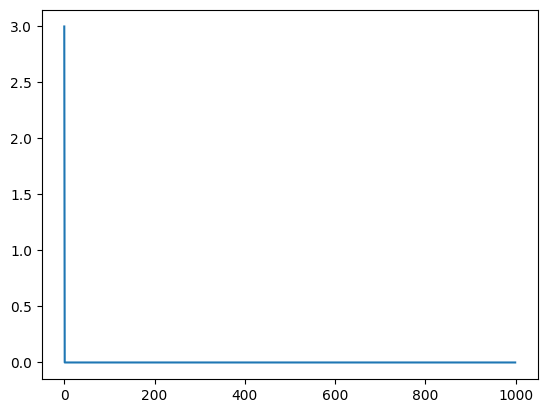

In [ ]:
output = torch.tensor(out)

plt.plot(output.numpy())
plt.show()